### This is a simple notebook to train a Support Vector Machine to discriminate between two types of collisional events. This week, we'll deal with data preprocessing, try out a simple Linear SVM, and diagnose its performance.

It accompanies Chapter 4 of the book.

Data for this exercise were kindly provided by [Sascha Caron](https://www.nikhef.nl/~scaron/).

Copyright: Viviana Acquaviva (2023)

Modifications by Julieta Gruszko (2025)

License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)




### Group names

Henry Holland, Ben Tonnesen

In [2]:
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.svm import SVC, LinearSVC # New algorithm!
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn import metrics

In [3]:
pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_colwidth', 100)
rc('text', usetex=False)

### The first part of this notebook walks through the manipulation I did to get the data in the format we need and to select a random sample to keep computation times more manageable.

This csv data set is a bit tricky to deal with: it has two different delimeters, ';' and ','. 

The semicolons separate the first 5 columns, which apply to the full event, and are also used to separate the lists of info about each of the products detected. So using the semicolons as a separator would give you:
$$\texttt{numID; processID; weight; MET; METphi; P1\_info; P2\_info; P3\_info; ...}$$

Commas are used to separate info about each of the products, so for each of the "Pn_info" columns separated by semicolons, there's a comma-separated list of the label and 4-momentum values:
$$\texttt{Pn\_info = Pn\_label, P\_E, Pn\_pt, Pn\_eta, Pn\_phi}$$

First, we'll make an array for the column labels, allowing for up to 19 products per event.

In [4]:
# make an array of column labels
names = np.array(['numID', 'processID', 'weight', 'MET', 'METphi'])
names = np.append(names, [['P'+str(i)+'_type', 'P'+str(i)+'_E', 'P'+str(i)+'_pt', 'P'+str(i)+'_eta', 'P'+str(i)+'_phi'] for i in range(19)])
print(names)


['numID' 'processID' 'weight' 'MET' 'METphi' 'P0_type' 'P0_E' 'P0_pt'
 'P0_eta' 'P0_phi' 'P1_type' 'P1_E' 'P1_pt' 'P1_eta' 'P1_phi' 'P2_type'
 'P2_E' 'P2_pt' 'P2_eta' 'P2_phi' 'P3_type' 'P3_E' 'P3_pt' 'P3_eta'
 'P3_phi' 'P4_type' 'P4_E' 'P4_pt' 'P4_eta' 'P4_phi' 'P5_type' 'P5_E'
 'P5_pt' 'P5_eta' 'P5_phi' 'P6_type' 'P6_E' 'P6_pt' 'P6_eta' 'P6_phi'
 'P7_type' 'P7_E' 'P7_pt' 'P7_eta' 'P7_phi' 'P8_type' 'P8_E' 'P8_pt'
 'P8_eta' 'P8_phi' 'P9_type' 'P9_E' 'P9_pt' 'P9_eta' 'P9_phi' 'P10_type'
 'P10_E' 'P10_pt' 'P10_eta' 'P10_phi' 'P11_type' 'P11_E' 'P11_pt'
 'P11_eta' 'P11_phi' 'P12_type' 'P12_E' 'P12_pt' 'P12_eta' 'P12_phi'
 'P13_type' 'P13_E' 'P13_pt' 'P13_eta' 'P13_phi' 'P14_type' 'P14_E'
 'P14_pt' 'P14_eta' 'P14_phi' 'P15_type' 'P15_E' 'P15_pt' 'P15_eta'
 'P15_phi' 'P16_type' 'P16_E' 'P16_pt' 'P16_eta' 'P16_phi' 'P17_type'
 'P17_E' 'P17_pt' 'P17_eta' 'P17_phi' 'P18_type' 'P18_E' 'P18_pt'
 'P18_eta' 'P18_phi']


Pandas can use python's regular expressions parsing engine to accept a more complex delimeter expression, so we can still read in the csv data file in one line.

In [5]:
df = pd.read_csv('../Data/TrainingValidationData.csv', delimiter=';|,', engine = 'python', names=names)
print(df.columns)

Index(['numID', 'processID', 'weight', 'MET', 'METphi', 'P0_type', 'P0_E',
       'P0_pt', 'P0_eta', 'P0_phi', 'P1_type', 'P1_E', 'P1_pt', 'P1_eta',
       'P1_phi', 'P2_type', 'P2_E', 'P2_pt', 'P2_eta', 'P2_phi', 'P3_type',
       'P3_E', 'P3_pt', 'P3_eta', 'P3_phi', 'P4_type', 'P4_E', 'P4_pt',
       'P4_eta', 'P4_phi', 'P5_type', 'P5_E', 'P5_pt', 'P5_eta', 'P5_phi',
       'P6_type', 'P6_E', 'P6_pt', 'P6_eta', 'P6_phi', 'P7_type', 'P7_E',
       'P7_pt', 'P7_eta', 'P7_phi', 'P8_type', 'P8_E', 'P8_pt', 'P8_eta',
       'P8_phi', 'P9_type', 'P9_E', 'P9_pt', 'P9_eta', 'P9_phi', 'P10_type',
       'P10_E', 'P10_pt', 'P10_eta', 'P10_phi', 'P11_type', 'P11_E', 'P11_pt',
       'P11_eta', 'P11_phi', 'P12_type', 'P12_E', 'P12_pt', 'P12_eta',
       'P12_phi', 'P13_type', 'P13_E', 'P13_pt', 'P13_eta', 'P13_phi',
       'P14_type', 'P14_E', 'P14_pt', 'P14_eta', 'P14_phi', 'P15_type',
       'P15_E', 'P15_pt', 'P15_eta', 'P15_phi', 'P16_type', 'P16_E', 'P16_pt',
       'P16_eta', 'P16_phi', 'P

In [6]:
df.head()

,numID,processID,weight,MET,METphi,P0_type,P0_E,P0_pt,P0_eta,P0_phi,P1_type,P1_E,P1_pt,P1_eta,P1_phi,P2_type,P2_E,P2_pt,P2_eta,P2_phi,P3_type,P3_E,P3_pt,P3_eta,P3_phi,P4_type,P4_E,P4_pt,P4_eta,P4_phi,P5_type,P5_E,P5_pt,P5_eta,P5_phi,P6_type,P6_E,P6_pt,P6_eta,P6_phi,P7_type,P7_E,P7_pt,P7_eta,P7_phi,P8_type,P8_E,P8_pt,P8_eta,P8_phi,P9_type,P9_E,P9_pt,P9_eta,P9_phi,P10_type,P10_E,P10_pt,P10_eta,P10_phi,P11_type,P11_E,P11_pt,P11_eta,P11_phi,P12_type,P12_E,P12_pt,P12_eta,P12_phi,P13_type,P13_E,P13_pt,P13_eta,P13_phi,P14_type,P14_E,P14_pt,P14_eta,P14_phi,P15_type,P15_E,P15_pt,P15_eta,P15_phi,P16_type,P16_E,P16_pt,P16_eta,P16_phi,P17_type,P17_E,P17_pt,P17_eta,P17_phi,P18_type,P18_E,P18_pt,P18_eta,P18_phi
0,0,ttbar,1.677790e-03,17742.1,-2.373670,j,193103.0,143393.0,0.803969,-0.198431,j,778814.0,104707.0,2.695040,-3.039080,j,125976.0,85268.9,-0.934506,3.102500,b,69106.5,55957.8,-0.661401,0.937923,j,50482.4,39522.4,0.687292,0.839734,j,82162.7,37182.8,1.426130,-0.074955,j,638681.0,24114.8,-3.96928,3.13769,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,ttbar,1.677790e-03,15567.8,-2.900150,b,183399.0,105032.0,1.153790,-2.435490,j,166852.0,93020.5,1.186420,0.203206,j,49938.5,48836.5,0.136584,0.006722,j,168744.0,23995.2,-2.637880,2.311970,e+,32046.3,27560.8,0.563054,1.710340,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,ttbar,3.341950e-02,30647.2,2.743360,j,420301.0,135727.0,-1.792050,-0.609116,j,294268.0,78516.8,-1.994660,-2.513450,b,194433.0,67511.8,-1.716620,0.314709,j,78721.8,50067.6,1.014570,1.725460,j,60548.4,50035.6,0.620308,2.794990,b,41859.8,39719.8,-0.279838,-3.047370,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,4top,1.931320e-07,27699.6,0.617912,j,300154.0,277869.0,-0.370231,-0.684062,j,261232.0,206121.0,0.698378,1.816920,j,258771.0,166742.0,-1.006300,-1.880100,j,145917.0,142031.0,0.159003,2.475230,j,67064.7,46427.1,-0.888082,2.222810,j,328441.0,43982.4,2.698900,0.061080,j,62307.4,28564.1,1.39952,-2.89200,m+,65374.6,53015.1,-0.670218,0.241486,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,ttbar,1.677790e-03,92205.9,1.574250,j,140760.0,75721.7,-1.225510,-2.926160,j,1650250.0,68573.0,-3.873460,-0.941662,j,199485.0,39008.3,-2.314910,-2.152160,j,36111.1,32994.1,-0.399817,1.252750,j,133019.0,29239.5,-2.194640,-0.139270,m-,31258.4,27580.9,-0.510817,2.757580,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We can use the $\texttt{describe}$ function to look at the numerical columns. The ATLAS detector calorimeter accepts tracks with $ -4.9 < \eta < 4.9$ and any value of azimuthal angle ($-\pi < \phi < \pi$). You can see nearly the full range of allowed values for these columns present in the P0 track. 

If you scroll all the way over to the final columns, you can see that we have some empty ones. We'll drop those below.

In [7]:
df.describe()

,numID,weight,MET,METphi,P0_E,P0_pt,P0_eta,P0_phi,P1_E,P1_pt,P1_eta,P1_phi,P2_E,P2_pt,P2_eta,P2_phi,P3_E,P3_pt,P3_eta,P3_phi,P4_E,P4_pt,P4_eta,P4_phi,P5_E,P5_pt,P5_eta,P5_phi,P6_E,P6_pt,P6_eta,P6_phi,P7_E,P7_pt,P7_eta,P7_phi,P8_E,P8_pt,P8_eta,P8_phi,P9_E,P9_pt,P9_eta,P9_phi,P10_E,P10_pt,P10_eta,P10_phi,P11_E,P11_pt,P11_eta,P11_phi,P12_E,P12_pt,P12_eta,P12_phi,P13_E,P13_pt,P13_eta,P13_phi,P14_E,P14_pt,P14_eta,P14_phi,P15_E,P15_pt,P15_eta,P15_phi,P16_E,P16_pt,P16_eta,P16_phi,P17_E,P17_pt,P17_eta,P17_phi,P18_type,P18_E,P18_pt,P18_eta,P18_phi
count,100000.000000,1.000000e+05,1.000000e+05,100000.000000,9.999700e+04,9.999700e+04,99997.000000,99997.000000,9.992600e+04,9.992600e+04,99926.000000,99926.000000,9.899100e+04,98991.000000,98991.000000,98991.000000,9.385300e+04,93853.000000,93853.000000,93853.000000,7.991000e+04,79910.000000,79910.000000,79910.000000,5.853900e+04,58539.000000,58539.000000,58539.000000,3.834700e+04,38347.000000,38347.000000,38347.000000,2.412200e+04,24122.000000,24122.000000,24122.000000,1.513400e+04,15134.000000,15134.000000,15134.000000,9.011000e+03,9011.000000,9011.000000,9011.000000,4.853000e+03,4853.000000,4853.000000,4853.000000,2.361000e+03,2361.000000,2361.000000,2361.000000,9.670000e+02,967.000000,967.000000,967.000000,3.420000e+02,342.000000,342.000000,342.000000,1.010000e+02,101.000000,101.000000,101.000000,27.000000,27.000000,27.000000,27.000000,5.000000,5.000000,5.000000,5.000000,1.0,1.0,1.000000,1.00000,0.0,0.0,0.0,0.0,0.0
mean,49999.500000,2.768161e-03,6.555098e+04,-0.002388,3.277655e+05,1.545569e+05,-0.003555,0.007387,2.502158e+05,1.077661e+05,0.002952,0.006567,2.060598e+05,74817.281537,-0.002819,0.003892,1.824161e+05,57910.555406,-0.002839,0.016402,1.721824e+05,48861.000075,-0.004951,-0.002767,1.684729e+05,44167.725923,-0.002462,-0.009561,1.664557e+05,41661.123342,-0.000830,0.005769,1.651800e+05,40757.138956,0.003005,0.001303,1.654103e+05,40760.175268,0.000550,-0.011165,1.615391e+05,40610.894030,0.013680,-0.003164,1.570275e+05,38895.164290,-0.025059,-0.029405,1.603781e+05,38429.168022,-0.035858,-0.019246,1.616734e+05,38770.992037,-0.040558,0.003644,1.829559e+05,38320.735965,-0.178360,0.032329,1.691126e+05,38722.138614,0.101772,0.031183,145489.218519,35810.907407,0.211409,0.035686,156263.780000,50542.640000,-1.153199,0.969473,27954.3,26642.3,0.244475,-1.76296,NaN,NaN,NaN,NaN,NaN
std,28867.657797,6.546279e-03,6.264809e+04,1.815031,2.992857e+05,1.123455e+05,1.350584,1.810318,2.563849e+05,7.614375e+04,1.422386,1.819205,2.472275e+05,44171.199946,1.542322,1.813828,2.388193e+05,31288.049544,1.640667,1.814603,2.406316e+05,25329.276228,1.721809,1.803750,2.368950e+05,22788.335816,1.788698,1.813985,2.337867e+05,22879.841904,1.834066,1.819974,2.340694e+05,25917.855025,1.852271,1.807746,2.272069e+05,30147.319141,1.878538,1.809817,2.197876e+05,34899.356724,1.881599,1.801553,2.123164e+05,31830.501192,1.894229,1.835047,2.151410e+05,32762.774784,1.932522,1.806983,2.074495e+05,34184.668553,1.967807,1.798218,2.537085e+05,31200.184143,2.053853,1.762871,1.931241e+05,54904.694281,2.108284,1.751026,180146.650481,20716.139614,1.918930,1.716581,166601.271942,54383.872168,1.691099,1.246147,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.931320e-07,1.574180e+02,-3.141550,2.089250e+04,1.838530e+04,-4.856300,-3.141520,1.087540e+04,1.007280e+04,-4.788360,-3.141420,1.027220e+04,10023.400000,-4.892440,-3.141570,1.001200e+04,10004.200000,-4.897010,-3.141540,1.034400e+04,10006.000000,-4.893080,-3.141110,1.028280e+04,10006.500000,-4.930230,-3.141500,1.013400e+04,10009.700000,-4.920570,-3.141530,1.048510e+04,10060.300000,-4.921770,-3.141430,1.022420e+04,10009.300000,-4.884880,-3.141580,1.047610e+04,10046.100000,-4.814330,-3.141510,1.116940e+04,10047.300000,-4.841310,-3.139450,1.068020e+04,10024.700000,-4.802890,-3.139820,1.163680e+04,10051.900000,-4.641500,-3.117420,1.094460e+04,10063.000000,-4.796960,-3.141480,1.276930e+04,12251.100000,-4.589180,-3.070980,25702.900000,22616.000000,-3.939780,-2.555390,32726.900000,23929.5000

In [8]:
X = df.drop(['numID', 'processID', 'weight'], axis = 1) #drop indices, labels, and weights (used to weigh statistics in simulation studies of spectra)
X = X.drop(['P18_type', 'P18_E', 'P18_pt', 'P18_eta', 'P18_phi'], axis = 1) #drop empty columns
X.describe()

,MET,METphi,P0_E,P0_pt,P0_eta,P0_phi,P1_E,P1_pt,P1_eta,P1_phi,P2_E,P2_pt,P2_eta,P2_phi,P3_E,P3_pt,P3_eta,P3_phi,P4_E,P4_pt,P4_eta,P4_phi,P5_E,P5_pt,P5_eta,P5_phi,P6_E,P6_pt,P6_eta,P6_phi,P7_E,P7_pt,P7_eta,P7_phi,P8_E,P8_pt,P8_eta,P8_phi,P9_E,P9_pt,P9_eta,P9_phi,P10_E,P10_pt,P10_eta,P10_phi,P11_E,P11_pt,P11_eta,P11_phi,P12_E,P12_pt,P12_eta,P12_phi,P13_E,P13_pt,P13_eta,P13_phi,P14_E,P14_pt,P14_eta,P14_phi,P15_E,P15_pt,P15_eta,P15_phi,P16_E,P16_pt,P16_eta,P16_phi,P17_E,P17_pt,P17_eta,P17_phi
count,1.000000e+05,100000.000000,9.999700e+04,9.999700e+04,99997.000000,99997.000000,9.992600e+04,9.992600e+04,99926.000000,99926.000000,9.899100e+04,98991.000000,98991.000000,98991.000000,9.385300e+04,93853.000000,93853.000000,93853.000000,7.991000e+04,79910.000000,79910.000000,79910.000000,5.853900e+04,58539.000000,58539.000000,58539.000000,3.834700e+04,38347.000000,38347.000000,38347.000000,2.412200e+04,24122.000000,24122.000000,24122.000000,1.513400e+04,15134.000000,15134.000000,15134.000000,9.011000e+03,9011.000000,9011.000000,9011.000000,4.853000e+03,4853.000000,4853.000000,4853.000000,2.361000e+03,2361.000000,2361.000000,2361.000000,9.670000e+02,967.000000,967.000000,967.000000,3.420000e+02,342.000000,342.000000,342.000000,1.010000e+02,101.000000,101.000000,101.000000,27.000000,27.000000,27.000000,27.000000,5.000000,5.000000,5.000000,5.000000,1.0,1.0,1.000000,1.00000
mean,6.555098e+04,-0.002388,3.277655e+05,1.545569e+05,-0.003555,0.007387,2.502158e+05,1.077661e+05,0.002952,0.006567,2.060598e+05,74817.281537,-0.002819,0.003892,1.824161e+05,57910.555406,-0.002839,0.016402,1.721824e+05,48861.000075,-0.004951,-0.002767,1.684729e+05,44167.725923,-0.002462,-0.009561,1.664557e+05,41661.123342,-0.000830,0.005769,1.651800e+05,40757.138956,0.003005,0.001303,1.654103e+05,40760.175268,0.000550,-0.011165,1.615391e+05,40610.894030,0.013680,-0.003164,1.570275e+05,38895.164290,-0.025059,-0.029405,1.603781e+05,38429.168022,-0.035858,-0.019246,1.616734e+05,38770.992037,-0.040558,0.003644,1.829559e+05,38320.735965,-0.178360,0.032329,1.691126e+05,38722.138614,0.101772,0.031183,145489.218519,35810.907407,0.211409,0.035686,156263.780000,50542.640000,-1.153199,0.969473,27954.3,26642.3,0.244475,-1.76296
std,6.264809e+04,1.815031,2.992857e+05,1.123455e+05,1.350584,1.810318,2.563849e+05,7.614375e+04,1.422386,1.819205,2.472275e+05,44171.199946,1.542322,1.813828,2.388193e+05,31288.049544,1.640667,1.814603,2.406316e+05,25329.276228,1.721809,1.803750,2.368950e+05,22788.335816,1.788698,1.813985,2.337867e+05,22879.841904,1.834066,1.819974,2.340694e+05,25917.855025,1.852271,1.807746,2.272069e+05,30147.319141,1.878538,1.809817,2.197876e+05,34899.356724,1.881599,1.801553,2.123164e+05,31830.501192,1.894229,1.835047,2.151410e+05,32762.774784,1.932522,1.806983,2.074495e+05,34184.668553,1.967807,1.798218,2.537085e+05,31200.184143,2.053853,1.762871,1.931241e+05,54904.694281,2.108284,1.751026,180146.650481,20716.139614,1.918930,1.716581,166601.271942,54383.872168,1.691099,1.246147,NaN,NaN,NaN,NaN
min,1.574180e+02,-3.141550,2.089250e+04,1.838530e+04,-4.856300,-3.141520,1.087540e+04,1.007280e+04,-4.788360,-3.141420,1.027220e+04,10023.400000,-4.892440,-3.141570,1.001200e+04,10004.200000,-4.897010,-3.141540,1.034400e+04,10006.000000,-4.893080,-3.141110,1.028280e+04,10006.500000,-4.930230,-3.141500,1.013400e+04,10009.700000,-4.920570,-3.141530,1.048510e+04,10060.300000,-4.921770,-3.141430,1.022420e+04,10009.300000,-4.884880,-3.141580,1.047610e+04,10046.100000,-4.814330,-3.141510,1.116940e+04,10047.300000,-4.841310,-3.139450,1.068020e+04,10024.700000,-4.802890,-3.139820,1.163680e+04,10051.900000,-4.641500,-3.117420,1.094460e+04,10063.000000,-4.796960,-3.141480,1.276930e+04,12251.100000,-4.589180,-3.070980,25702.900000,22616.000000,-3.939780,-2.555390,32726.900000,23929.500000,-3.514450,-0.453093,27954.3,26642.3,0.244475,-1.76296
25%,2.466453e+04,-1.577830,1.371900e+05,8.806960e+04,-0.987878,-1.553980,9.961973e+04,6.373630e+04,-1.009580,-1.571915,7.534165e+04,47026.900000,-1.078880,

In [9]:
len(df.columns)

100

In [10]:
X.head() 

,MET,METphi,P0_type,P0_E,P0_pt,P0_eta,P0_phi,P1_type,P1_E,P1_pt,P1_eta,P1_phi,P2_type,P2_E,P2_pt,P2_eta,P2_phi,P3_type,P3_E,P3_pt,P3_eta,P3_phi,P4_type,P4_E,P4_pt,P4_eta,P4_phi,P5_type,P5_E,P5_pt,P5_eta,P5_phi,P6_type,P6_E,P6_pt,P6_eta,P6_phi,P7_type,P7_E,P7_pt,P7_eta,P7_phi,P8_type,P8_E,P8_pt,P8_eta,P8_phi,P9_type,P9_E,P9_pt,P9_eta,P9_phi,P10_type,P10_E,P10_pt,P10_eta,P10_phi,P11_type,P11_E,P11_pt,P11_eta,P11_phi,P12_type,P12_E,P12_pt,P12_eta,P12_phi,P13_type,P13_E,P13_pt,P13_eta,P13_phi,P14_type,P14_E,P14_pt,P14_eta,P14_phi,P15_type,P15_E,P15_pt,P15_eta,P15_phi,P16_type,P16_E,P16_pt,P16_eta,P16_phi,P17_type,P17_E,P17_pt,P17_eta,P17_phi
0,17742.1,-2.373670,j,193103.0,143393.0,0.803969,-0.198431,j,778814.0,104707.0,2.695040,-3.039080,j,125976.0,85268.9,-0.934506,3.102500,b,69106.5,55957.8,-0.661401,0.937923,j,50482.4,39522.4,0.687292,0.839734,j,82162.7,37182.8,1.426130,-0.074955,j,638681.0,24114.8,-3.96928,3.13769,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
1,15567.8,-2.900150,b,183399.0,105032.0,1.153790,-2.435490,j,166852.0,93020.5,1.186420,0.203206,j,49938.5,48836.5,0.136584,0.006722,j,168744.0,23995.2,-2.637880,2.311970,e+,32046.3,27560.8,0.563054,1.710340,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
2,30647.2,2.743360,j,420301.0,135727.0,-1.792050,-0.609116,j,294268.0,78516.8,-1.994660,-2.513450,b,194433.0,67511.8,-1.716620,0.314709,j,78721.8,50067.6,1.014570,1.725460,j,60548.4,50035.6,0.620308,2.794990,b,41859.8,39719.8,-0.279838,-3.047370,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
3,27699.6,0.617912,j,300154.0,277869.0,-0.370231,-0.684062,j,261232.0,206121.0,0.698378,1.816920,j,258771.0,166742.0,-1.006300,-1.880100,j,145917.0,142031.0,0.159003,2.475230,j,67064.7,46427.1,-0.888082,2.222810,j,328441.0,43982.4,2.698900,0.061080,j,62307.4,28564.1,1.39952,-2.89200,m+,65374.6,53015.1,-0.670218,0.241486,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN
4,92205.9,1.574250,j,140760.0,75721.7,-1.225510,-2.926160,j,1650250.0,68573.0,-3.873460,-0.941662,j,199485.0,39008.3,-2.314910,-2.152160,j,36111.1,32994.1,-0.399817,1.252750,j,133019.0,29239.5,-2.194640,-0.139270,m-,31258.4,27580.9,-0.510817,2.757580,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,NaN


### Saving subset of the data to a new file

We'll select 5000 random instances to reduce the size of the data set, reset the indices of both the features and labels, and store both to csv files. That will let us load the same data more easily if we want to work with it again (e.g. in next week's studio).


First, we'll generate a random list of event indices to select 5000 events. We'll set the seed so everyone is using the same subset.

In [11]:
np.random.seed(10)

sel = np.random.choice(df.shape[0], 5000)

Now, we'll select those rows from the feature data frame and save the subset to a file.

In [12]:
features = X.iloc[sel,:]

print(features.shape)
print(features.columns)

# reset index
features.reset_index(drop=True, inplace=True)
features.head()

# Export the feature data to a file
features.to_csv('../Data/ParticleID_features.csv', columns=features.columns, index_label= 'ID')

(5000, 92)
Index(['MET', 'METphi', 'P0_type', 'P0_E', 'P0_pt', 'P0_eta', 'P0_phi',
       'P1_type', 'P1_E', 'P1_pt', 'P1_eta', 'P1_phi', 'P2_type', 'P2_E',
       'P2_pt', 'P2_eta', 'P2_phi', 'P3_type', 'P3_E', 'P3_pt', 'P3_eta',
       'P3_phi', 'P4_type', 'P4_E', 'P4_pt', 'P4_eta', 'P4_phi', 'P5_type',
       'P5_E', 'P5_pt', 'P5_eta', 'P5_phi', 'P6_type', 'P6_E', 'P6_pt',
       'P6_eta', 'P6_phi', 'P7_type', 'P7_E', 'P7_pt', 'P7_eta', 'P7_phi',
       'P8_type', 'P8_E', 'P8_pt', 'P8_eta', 'P8_phi', 'P9_type', 'P9_E',
       'P9_pt', 'P9_eta', 'P9_phi', 'P10_type', 'P10_E', 'P10_pt', 'P10_eta',
       'P10_phi', 'P11_type', 'P11_E', 'P11_pt', 'P11_eta', 'P11_phi',
       'P12_type', 'P12_E', 'P12_pt', 'P12_eta', 'P12_phi', 'P13_type',
       'P13_E', 'P13_pt', 'P13_eta', 'P13_phi', 'P14_type', 'P14_E', 'P14_pt',
       'P14_eta', 'P14_phi', 'P15_type', 'P15_E', 'P15_pt', 'P15_eta',
       'P15_phi', 'P16_type', 'P16_E', 'P16_pt', 'P16_eta', 'P16_phi',
       'P17_type', 'P17_E', 'P

#### Now, the labels

In [13]:
#Select the labels
y = df.processID[sel].values # values makes it an array
print(y)
#Export labels to file
np.savetxt('../Data/ParticleID_labels.txt', y, fmt = '%s')

['ttbar' 'ttbar' 'ttbar' ... 'ttbar' '4top' 'ttbar']


## Now we're ready to start!

Read in features and labels.

In [14]:
features = pd.read_csv('../Data/ParticleID_features.csv', index_col='ID')

In [15]:
features.head()

,MET,METphi,P0_type,P0_E,P0_pt,P0_eta,P0_phi,P1_type,P1_E,P1_pt,P1_eta,P1_phi,P2_type,P2_E,P2_pt,P2_eta,P2_phi,P3_type,P3_E,P3_pt,P3_eta,P3_phi,P4_type,P4_E,P4_pt,P4_eta,P4_phi,P5_type,P5_E,P5_pt,P5_eta,P5_phi,P6_type,P6_E,P6_pt,P6_eta,P6_phi,P7_type,P7_E,P7_pt,P7_eta,P7_phi,P8_type,P8_E,P8_pt,P8_eta,P8_phi,P9_type,P9_E,P9_pt,P9_eta,P9_phi,P10_type,P10_E,P10_pt,P10_eta,P10_phi,P11_type,P11_E,P11_pt,P11_eta,P11_phi,P12_type,P12_E,P12_pt,P12_eta,P12_phi,P13_type,P13_E,P13_pt,P13_eta,P13_phi,P14_type,P14_E,P14_pt,P14_eta,P14_phi,P15_type,P15_E,P15_pt,P15_eta,P15_phi,P16_type,P16_E,P16_pt,P16_eta,P16_phi,P17_type,P17_E,P17_pt,P17_eta,P17_phi
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,127932.0,0.826569,2.332000,b,86788.9,84554.9,-0.180795,2.187970,j,140289.0,76955.8,-1.19933,-1.302800,m+,85230.6,70102.4,-0.645689,-1.659540,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,57594.2,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,68462.9,-2.126740,-2.582310,e-,44270.1,35139.6,-0.706120,-0.371392,e+,72883.9,26902.2,-1.65386,-3.129630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,82313.3,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,54922.3,1.226850,0.646589,j,60768.9,36244.3,1.102890,-1.434480,j,77714.0,27801.5,1.68461,1.389690,j,26840.0,24469.3,-0.388937,-1.647260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30610.8,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,39472.0,-0.024646,-2.222800,j,201589.0,32978.6,-2.496040,1.137810,j,90096.7,26964.5,1.87132,0.817631,j,28235.4,25887.9,-0.411528,2.024290,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,45153.1,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,69762.1,0.774114,2.568740,j,61625.2,50086.7,0.652572,-3.012800,j,104193.0,31151.0,1.87641,0.865381,j,746585.0,26219.3,4.041820,-0.874169,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
features.shape

(5000, 92)

In [17]:
y = np.genfromtxt('../Data/ParticleID_labels.txt', dtype = str)

In [18]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      shape=(5000,), dtype='<U5')

#### We need to turn categorical (string-type) labels into an array, e.g. 0/1.

sk-learn has a nice preprocessing tool we can use for this. 

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder() #turns categorical into 1 ... N

In [20]:
y

array(['ttbar', 'ttbar', 'ttbar', ..., 'ttbar', '4top', 'ttbar'],
      shape=(5000,), dtype='<U5')

In [21]:
y = le.fit_transform(y)

In [22]:
y 

array([1, 1, 1, ..., 1, 0, 1], shape=(5000,))

Our transformer used 1 for the first instance, but we actually wanted 4top to be the positive label, so we'll flip the labels:

In [23]:
target = np.abs(y - 1)

In [24]:
target # Happier now.

array([0, 0, 0, ..., 0, 1, 0], shape=(5000,))

#### Let's take a look at these features, using the "describe" property.

In [25]:
features.describe() #Note that this automatically excludes non-numerical type columns

,MET,METphi,P0_E,P0_pt,P0_eta,P0_phi,P1_E,P1_pt,P1_eta,P1_phi,P2_E,P2_pt,P2_eta,P2_phi,P3_E,P3_pt,P3_eta,P3_phi,P4_E,P4_pt,P4_eta,P4_phi,P5_E,P5_pt,P5_eta,P5_phi,P6_E,P6_pt,P6_eta,P6_phi,P7_E,P7_pt,P7_eta,P7_phi,P8_E,P8_pt,P8_eta,P8_phi,P9_E,P9_pt,P9_eta,P9_phi,P10_E,P10_pt,P10_eta,P10_phi,P11_E,P11_pt,P11_eta,P11_phi,P12_E,P12_pt,P12_eta,P12_phi,P13_E,P13_pt,P13_eta,P13_phi,P14_E,P14_pt,P14_eta,P14_phi,P15_type,P15_E,P15_pt,P15_eta,P15_phi,P16_type,P16_E,P16_pt,P16_eta,P16_phi,P17_type,P17_E,P17_pt,P17_eta,P17_phi
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000,4.002000e+03,4002.000000,4002.000000,4002.000000,2.871000e+03,2871.00000,2871.000000,2871.000000,1.889000e+03,1889.000000,1889.000000,1889.000000,1.186000e+03,1186.000000,1186.000000,1186.000000,7.290000e+02,729.000000,729.000000,729.000000,4.420000e+02,442.000000,442.000000,442.000000,2.610000e+02,261.000000,261.000000,261.000000,1.270000e+02,127.000000,127.000000,127.000000,5.600000e+01,56.000000,56.000000,56.000000,14.000000,14.000000,14.000000,14.000000,3.000000,3.000000,3.000000,3.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266,1.780366e+05,48798.018516,0.015167,-0.031312,1.705620e+05,44042.67015,-0.022948,0.014522,1.628825e+05,41151.069666,0.002228,0.006738,1.581409e+05,40250.387015,0.072349,-0.035907,1.596814e+05,40139.289849,0.061654,-0.045868,1.574039e+05,39703.038235,0.118543,0.024249,1.561160e+05,38173.716092,0.029455,0.026422,1.631051e+05,34876.849606,0.206978,-0.001085,1.456600e+05,36151.183929,-0.000879,0.219260,180401.885714,27076.621429,-0.276634,0.595697,205102.000000,24610.900000,-1.333743,1.518666,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078,2.577958e+05,26252.978520,1.744489,1.784248,2.381745e+05,23510.65367,1.806611,1.811101,2.269341e+05,20988.953157,1.815312,1.771888,2.118782e+05,26556.025657,1.836492,1.796932,2.308620e+05,30074.756789,1.842798,1.788596,2.165489e+05,30502.312276,1.872084,1.826435,2.319016e+05,29324.658352,1.884750,1.753017,2.248603e+05,20433.767238,1.998859,1.949004,1.943657e+05,25861.883410,1.941707,1.910400,262972.929941,3332.496623,2.181392,1.760349,230084.978534,1916.495834,2.661912,1.672151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130,1.110310e+04,10287.000000,-4.778980,-3.139040,1.070330e+04,10066.90000,-4.930230,-3.140380,1.197700e+04,11260.200000,-4.758150,-3.135630,1.380860e+04,10973.300000,-4.606330,-3.132610,1.119760e+04,10067.900000,-4.814380,-3.136380,1.615530e+04,10183.700000,-4.803880,-3.135910,2.004750e+04,14800.200000,-4.400470,-3.130690,1.780380e+04,12987.900000,-4.447660,-3.139820,2.512510e+04,14836.000000,-4.448760,-2.990730,25937.400000,23170.800000,-4.072000,-2.709890,58941.000000,23025.500000,-3.709270,-0.201051,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030,5.278370e+04,30891.650000,-1.198468,-1.550615,5.007050e+04,28453.95000,-1.250050,-1.586675,4.695560e+04,27963.500000,-1.231420,-1.475380,4.535515e+04,27140.550000,-1.243962,-1.626688,4.387110e+04,26825.

### Important:

Looking at the "count" row, we can see that the whole data set has 5,000 rows, but some columns are present only for a fraction of them. This is because of the variable number of products in each collision.

#### Option 1: Only consider the missing energy features and the 4-momentum values of the first four products, so we have limited imputing/manipulation problems.

In our data set, the products are ordered by their energy, so choosing the first 4 should give us a lot of the relevant information.

For the moment, we'll work just with the numerical features. Next week, we'll see some options for incorporating the track types as additional features.

We have a trade-off between keeping more features, but having a more severe missing data/imputing problem, or keeping fewer features, but dealing with a simpler imputing problem. We are choosing the latter.

In [26]:
features_lim = features[['MET', 'METphi', 'P0_E', 'P0_pt', 'P0_eta', 'P0_phi', 'P1_E', 'P1_pt', 'P1_eta', 'P1_phi', 'P2_E', 'P2_pt', 'P2_eta', 'P2_phi', 'P3_E', 'P3_pt', 'P3_eta', 'P3_phi']]

In [27]:
features_lim.head()

,MET,METphi,P0_E,P0_pt,P0_eta,P0_phi,P1_E,P1_pt,P1_eta,P1_phi,P2_E,P2_pt,P2_eta,P2_phi,P3_E,P3_pt,P3_eta,P3_phi
ID,,,,,,,,,,,,,,,,,,
0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.19933,-1.302800
1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.65386,-3.129630
2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.68461,1.389690
3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.87132,0.817631
4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.87641,0.865381


In [28]:
features_lim.describe() #This automatically excludes non-numerical type columns, and missing values/NaNs are not counted.

,MET,METphi,P0_E,P0_pt,P0_eta,P0_phi,P1_E,P1_pt,P1_eta,P1_phi,P2_E,P2_pt,P2_eta,P2_phi,P3_E,P3_pt,P3_eta,P3_phi
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,4997.000000,4.950000e+03,4950.000000,4950.000000,4950.000000,4.717000e+03,4717.000000,4717.000000,4717.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,0.007327,2.117980e+05,74863.343131,-0.025104,0.011845,1.805997e+05,57289.049481,0.010723,0.045266
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,1.828832,2.510361e+05,46309.512365,1.577316,1.802715,2.383403e+05,32013.857623,1.634072,1.812078
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,-3.140530,1.221050e+04,10639.800000,-4.520250,-3.141480,1.169190e+04,10818.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,-1.602460,7.636905e+04,46549.475000,-1.125620,-1.547418,5.999090e+04,36097.700000,-1.121240,-1.518030
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057429,0.015111,1.288565e+05,62498.400000,-0.040648,0.034238,9.922610e+04,48949.200000,-0.035512,0.060279
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999950e+05,1.238700e+05,1.028340,1.605210,2.421225e+05,89587.500000,1.066302,1.570887,1.914340e+05,68782.100000,1.159480,1.612220
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


There are still some feature columns with different length! This means there might be NaN values. Let's replace them with 0 for the moment. 

In [29]:
features_lim = features_lim.fillna(0) #Fill with 0 everywhere there is a NaN

Note: this is the simplest but worst possible choice - imputing a constant value skews the model :D One step up would be to input the mean or median for each column. However, because only a limited number of instances have missing data, the choice of imputing strategy doesn't matter too much.

#### Let's see what "describe" says now.

In [30]:
features_lim.describe()

,MET,METphi,P0_E,P0_pt,P0_eta,P0_phi,P1_E,P1_pt,P1_eta,P1_phi,P2_E,P2_pt,P2_eta,P2_phi,P3_E,P3_pt,P3_eta,P3_phi
count,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000
mean,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704
std,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070
min,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130
25%,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080
50%,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000
75%,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765
max,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660


Yay - we now have consistent sizes, so we can use these as feature arrays, BUT be mindful of possible negative impacts of our imputing strategies.

### Let's move onto a quick exploration of labels and benchmarking.

In [31]:
np.sum(target)/len(target) #distribution 

np.float64(0.1622)

84\% in the negative label, 16\% in the positive label. 

This means that a classifier that puts everything in the negative class will have 84\% accuracy.

How about a random classifier that just assigns a random value according to class distribution?

In [ ]:
#Numerical solution

acc=0
for i in range(1000):
    x = np.random.choice(target,5000)
    acc += metrics.accuracy_score(target,x)
print(acc/1000)

#Analytic solution 

print(0.8378*(0.8378) + 0.1622*0.1622)

0.7282861999999997
0.72821768


### Question: 
Describe what the "numerical solution" code is doing to get an estimated accuracy for a random classifier. You can give a description or pseudocode, your choice. 

>Loops through 1..1000, and picks a random out of the target data set. Then it adds the accuracy to 'acc'. Then it averages 'acc' to give the average accuracy

In conclusion, a "random" classifier would have 73% accuracy; a "lazy" classifier that predicts the most frequent class would have 83% accuracy. These are useful in order to set the expectation for what "a good result" is and what constitutes a significant improvement.

### Let's start with a linear model; model = SVC()

Define a cross-validation strategy; establish benchmark for a linear model.

In [33]:
bmodel = LinearSVC(dual = False) #Prefer dual=False when n_samples > n_features. If not, will not converge!!

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=101) 

In [35]:
l_benchmark_lim = cross_validate(bmodel, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [36]:
l_benchmark_lim

{'fit_time': array([0.02380872, 0.00680876, 0.00594091, 0.00553203, 0.00650287]),
 'score_time': array([0.00157523, 0.00063324, 0.00054789, 0.00050902, 0.0004921 ]),
 'test_score': array([0.841, 0.825, 0.829, 0.83 , 0.833]),
 'train_score': array([0.8315 , 0.83275, 0.8315 , 0.83125, 0.832  ])}

In [39]:
print(np.round(l_benchmark_lim['test_score'].mean(),3), np.round(l_benchmark_lim['test_score'].std(), 3))

0.832 0.005


### Question:
Evaluate the performance of the inital Linear SVM you trained. Does it out-perform the "lazy" or random classifiers described above?

>The test score from the linear SVM is 0.832 with a standard deviation of 0.005. It out-performs the random classifier and performs the same as the lazy classifier. 

We can also check the predicted labels and the confusion matrix. Cross\_val\_predict will compile labels predicted when each object was in the test fold.

In [38]:
ypred_bench_lim = cross_val_predict(bmodel, features_lim, target, cv = cv)
metrics.confusion_matrix(target,ypred_bench_lim) 

array([[4132,   57],
       [ 785,   26]])

### Question:
How many 4-top events are missed by this classifier? How many non-4-top events are misidentified as 4-top events?

>57 4-top events are missed by this classifier (false negatives). 785 non-4-top events are misidentified as 4-top-events (false positivies). 

### Question: is there perhaps something that we should have done before building the SVM model?

>We could have scaled the data before building the model to remove the influence of outliers. Additionally, we could have chosen a quadratic model instead of a linear model to add additional depth to the model. 

### How about scaling?

Implementation notes: Technically, standardizing/normalizing data using the entire learning set introduces leakage between train and test set (the test set "knows" about the mean and standard deviation of the entire data set). Usually this is not a dramatic effect, but the correct procedure is to derive the scaler within each CV fold (i.e. after separating in train and test), only on the train set, and apply the same transformation to the test set. The model then becomes a pipeline.

In [40]:
from sklearn.pipeline import make_pipeline #This allows one to build different steps together

In [41]:
piped_model = make_pipeline(StandardScaler(), LinearSVC(dual = False)) #make a pipeline with standard scaler and linear SVM

piped_model.get_params() #return the parameters of the full pipeline. You should see some associeted with the the scaler, and some with the SVM algorithm

{'memory': None,
 'steps': [('standardscaler', StandardScaler()),
  ('linearsvc', LinearSVC(dual=False))],
 'transform_input': None,
 'verbose': False,
 'standardscaler': StandardScaler(),
 'linearsvc': LinearSVC(dual=False),
 'standardscaler__copy': True,
 'standardscaler__with_mean': True,
 'standardscaler__with_std': True,
 'linearsvc__C': 1.0,
 'linearsvc__class_weight': None,
 'linearsvc__dual': False,
 'linearsvc__fit_intercept': True,
 'linearsvc__intercept_scaling': 1,
 'linearsvc__loss': 'squared_hinge',
 'linearsvc__max_iter': 1000,
 'linearsvc__multi_class': 'ovr',
 'linearsvc__penalty': 'l2',
 'linearsvc__random_state': None,
 'linearsvc__tol': 0.0001,
 'linearsvc__verbose': 0}

Now that we have a pipeline, when we use cross-validation, then for each fold, it will run all the steps of the pipeline. In this case, that means that for each fold, it:
- applies standard scaling to the train data
- trains the linear SVM using this scaled train set, returning the train score
- scales the test data with standard scaling
- makes predictions for the test data, returning the accuracy score

In [42]:
benchmark_lim_piped = cross_validate(piped_model, features_lim, target, cv = cv, scoring = 'accuracy', return_train_score=True)

In [43]:
benchmark_lim_piped

{'fit_time': array([0.01923299, 0.00489402, 0.00578403, 0.004884  , 0.00418901]),
 'score_time': array([0.00140095, 0.00079107, 0.00074387, 0.000664  , 0.00064397]),
 'test_score': array([0.894, 0.889, 0.89 , 0.892, 0.899]),
 'train_score': array([0.89575, 0.89525, 0.895  , 0.89825, 0.89275])}

In [47]:
#get the mean and standard deviation of the test score
print(np.round(benchmark_lim_piped['test_score'].mean(),3), np.round(benchmark_lim_piped['test_score'].std(), 3))

0.893 0.004


In [46]:
#get the mean and standard deviation of the train score
print(np.round(benchmark_lim_piped['train_score'].mean(),3), np.round(benchmark_lim_piped['train_score'].std(), 3))

0.895 0.002


This is a significant improvement (woo-ooh!), and the comparison between test and train scores tells us already something about the problem that we have. We can formalize this by looking at the learning curves, which tell us both about gap between train/test scores, AND whether we need more data.

### Learning curves 

In [48]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=5,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5), scoring = 'accuracy', scale = False):
    """
    Generate a simple plot of the test and training learning curve.

    Parameters
    ----------
    estimator : object type that implements the "fit" and "predict" methods
        An object of that type which is cloned for each validation.

    title : string
        Title for the chart.

    X : array-like, shape (n_samples, n_features)
        Training vector, where n_samples is the number of samples and
        n_features is the number of features.

    y : array-like, shape (n_samples) or (n_samples, n_features), optional
        Target relative to X for classification or regression;
        None for unsupervised learning.

    ylim : tuple, shape (ymin, ymax), optional
        Defines minimum and maximum yvalues plotted.

    cv : int, cross-validation generator or an iterable, optional
        Determines the cross-validation splitting strategy.
        Possible inputs for cv are:
          - None, to use the default 3-fold cross-validation,
          - integer, to specify the number of folds.
          - :term:`CV splitter`,
          - An iterable yielding (train, test) splits as arrays of indices.

        For integer/None inputs, if ``y`` is binary or multiclass,
        :class:`StratifiedKFold` used. If the estimator is not a classifier
        or if ``y`` is neither binary nor multiclass, :class:`KFold` is used.

        Refer :ref:`User Guide <cross_validation>` for the various
        cross-validators that can be used here.

    n_jobs : int or None, optional (default=None)
        Number of jobs to run in parallel.
        ``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.
        ``-1`` means using all processors. See :term:`Glossary <n_jobs>`
        for more details.

    train_sizes : array-like, shape (n_ticks,), dtype float or int
        Relative or absolute numbers of training examples that will be used to
        generate the learning curve. If the dtype is float, it is regarded as a
        fraction of the maximum size of the training set (that is determined
        by the selected validation method), i.e. it has to be within (0, 1].
        Otherwise it is interpreted as absolute sizes of the training sets.
        Note that for classification the number of samples usually have to
        be big enough to contain at least one sample from each class.
        (default: np.linspace(0.1, 1.0, 5))
    """
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("# of training examples",fontsize = 14)
 
    plt.ylabel("Accuracy score",fontsize = 14)
    
    if (scale == True):
        scaler = sklearn.preprocessing.StandardScaler()
        X = scaler.fit_transform(X)
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring = scoring)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
#    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="b")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="b",
             label="Training score from CV")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
             label="Test score from CV")

    plt.legend(loc="best",fontsize = 12)
    return plt

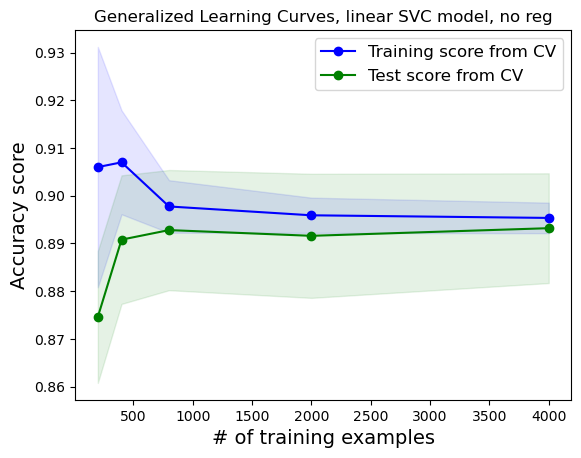

In [49]:
plot_learning_curve(piped_model, 'Generalized Learning Curves, linear SVC model, no reg', features_lim, target, train_sizes = np.array([0.05,0.1,0.2,0.5,1.0]), cv = KFold(n_splits=5, shuffle=True));

### Linear SVM Conclusion Questions

1. How does the classifier performance compare to "lazy" and random classifiers?
2. Briefly explain why scaling the data improved the SVM performance. You may find it helpful to think back to the different behavior we observed with respect to scaling effects in the Decision Tree and kNN algorithms. 
3. Does the model suffer from high variance, high bias, or both? How do you know?
4. Would you expect that having more data would improve the performance of the classifier? How do you know?
5. Given your diagnosis from questions 3 and 4, what are some things we should try to improve this classifier's performance? 



>1. The classifier performance is better than the "lazy" and random classifiers because it has a training score of 0.895. 
>2. We used StandardScalar which makes the mean 0 and the standard deviation 1. This is helpful because it reduces the standard deviation which makes the results have less variation. 
>3. The model has low variance and high bias. The shaded area is the variance and is relatively small. The bias is large beacuse the test data only fits the model with a training score of 0.895.
>4. No. The variance is low already so adding more data would not help the performance of the classifier. There is already a lot of data. 
>5. A more complex model would help with the high bias and underfitting. More data could be useful but especially if it fills out the area near the outliers because StandardScalar is weighted by the mean. 

### Acknowledgement statement:

>The authors recognize the use of Wikipedia and ChatGPT in understanding confusion matricies, bias, and variance. 

### When you're finished, submit this studio to Gradescope. 